## Figure 5

Analysis of Pax5 validation experiments.

Kexin Dong

Last Update: Mar 3, 2026

NEED TO BE UPDATED FOR: 

- guide number of the safe targeting control;
- show CBE validation screen data in parallel.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os
import functools
import upsetplot
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects

warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

yellows = sns.color_palette('Oranges').as_hex()
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
purples = sns.color_palette('Purples').as_hex()

## 5a - AACR B cell leukemia mutations

In [2]:
df_mutation_aacr = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v17.0/data_mutations_extended.txt',
                          header=0, sep='\t', comment="#", 
                          na_values=['Not Applicable', 'NA', 'NULL', '-', 'None', ''])
df_pts = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v17.0/data_clinical_patient.txt', header=0, sep='\t', comment="#", na_values = 'Not Applicable')
df_sample = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v17.0/data_clinical_sample.txt', header=0, sep='\t', comment="#", na_values = 'Not Applicable')

In [11]:
sample_id_b_cell_leukemia = df_sample[df_sample['CANCER_TYPE'].isin(['B-Lymphoblastic Leukemia/Lymphoma'])]['SAMPLE_ID'].unique()
df_mutation_aacr_b_cell_leukemia = df_mutation_aacr[df_mutation_aacr['Tumor_Sample_Barcode'].isin(sample_id_b_cell_leukemia)].reset_index(drop=True)
# df_mutation_aacr_leukemia = df_mutation_aacr_leukemia[df_mutation_aacr_leukemia['Variant_Type']== 'SNP'].reset_index(drop=True)
df_mutation_aacr_b_cell_leukemia

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,FILTER,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,n_depth,t_depth,Annotation_Status,mutationInCis_Flag
0,NPM1,4869.0,JHU,GRCh37,5,170837543,170837544,+,frameshift_variant,Frame_Shift_Ins,...,PASS,NaN,NaN,NaN,NaN,NaN,NaN,2107.0,SUCCESS,False
1,FLT3,2322.0,JHU,GRCh37,13,28592620,28592620,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,1.000,deleterious,0.00,NaN,NaN,2495.0,SUCCESS,False
2,PTPN11,5781.0,JHU,GRCh37,12,112926887,112926887,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,0.999,deleterious,0.03,NaN,NaN,2095.0,SUCCESS,False
3,IDH2,3418.0,JHU,GRCh37,15,90631934,90631934,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,0.987,deleterious_low_confidence,0.00,NaN,NaN,2015.0,SUCCESS,False
4,SMARCB1,6598.0,JHU,GRCh37,22,24176297,24176297,+,intron_variant,Intron,...,PASS,NaN,NaN,NaN,NaN,NaN,NaN,1474.0,SUCCESS,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6375,TP53,7157.0,UCHI,GRCh37,17,7577557,7577557,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,1.000,deleterious,0.00,NaN,NaN,1637.0,SUCCESS,False
6376,RET,5979.0,UCHI,GRCh37,10,43613843,43613843,+,synonymous_variant,Silent,...,PASS,NaN,NaN,NaN,NaN,NaN,NaN,4491.0,SUCCESS,False
6377,RET,5979.0,UCHI,GRCh37,10,43615633,43615633,+,synonymous_variant,Silent,...,PASS,NaN,NaN,NaN,NaN,NaN,NaN,5749.0,SUCCESS,False
6378,PTEN,5728.0,UCHI,GRCh37,10,89692896,89692896,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,1.000,deleterious,0.00,NaN,NaN,19417.0,SUCCESS,False


In [ ]:
df_b_cell_leukemia = df_mutation_aacr_b_cell_leukemia[['Hugo_Symbol', 'Entrez_Gene_Id', 'Chromosome', 'Start_Position', 'End_Position', 'Reference_Allele', 'Tumor_Seq_Allele2', 'Variant_Type', 'Variant_Classification', 'Strand', 'Tumor_Sample_Barcode']].drop_duplicates().reset_index(drop=True).copy()
df_b_cell_leukemia = df_b_cell_leukemia[df_b_cell_leukemia['Chromosome']!= 'MT'].reset_index(drop=True)
df_b_cell_leukemia = df_b_cell_leukemia[['Hugo_Symbol', 'Entrez_Gene_Id', 'Chromosome', 'Start_Position', 'End_Position', 'Reference_Allele', 'Tumor_Seq_Allele2', 'Variant_Type', 'Variant_Classification', 'Strand']].value_counts().reset_index()
df_b_cell_leukemia['Hugo_Symbol'].value_counts()

# to do: draw a bar plot of the Hugo_Symbol counts

Hugo_Symbol
TP53       97
KMT2D      74
MIR4457    62
CREBBP     48
NOTCH1     46
           ..
DDX31       1
CYSLTR2     1
MAML3       1
CUL3        1
ARID3A      1
Name: count, Length: 634, dtype: int64

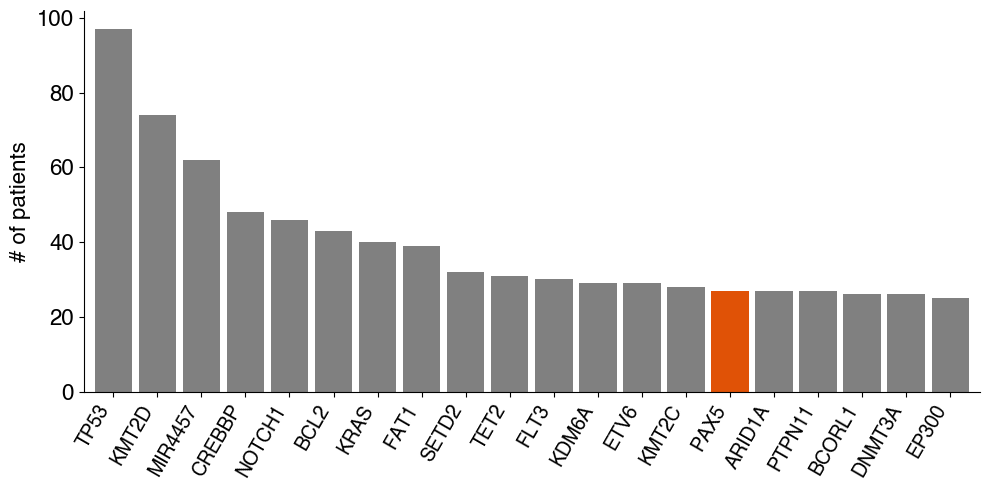

In [ ]:
hugo_counts = df_b_cell_leukemia['Hugo_Symbol'].value_counts()[:20]

colors = ['gray'] * len(hugo_counts)
for i, gene in enumerate(hugo_counts.index):
    if str(gene).upper() == 'PAX5':
        colors[i] = yellows[4]

fig, ax = plt.subplots(figsize=(10, 5))
hugo_counts.plot(kind='bar', ax=ax, color=colors,width=0.85)

ax.set_title('', fontsize=16)
ax.set_xlabel('', fontsize=14)
ax.set_ylabel('# of patients', fontsize=16)
plt.setp(ax.get_xticklabels(), rotation=60, ha='right', fontsize=14)
plt.setp(ax.get_yticklabels(), fontsize=16)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/5_1.pdf')
plt.show()

## 5b - CBE Screen Pax5 Distribution (Highlight candidates)

## 5c - Pax5 Protein Structure with highlighted residues

## 5d - Experimental Scheme

## 5e - Spleen, BM, meningee, and In Vitro Enrichment Comparison

## Process validation data

### BE

In [ ]:
sample = 'Pax5'
fp = os.path.join('validation', sample, 'BE')

flow_dict_BE = {}
for fname in os.listdir(fp):
    if fname.endswith('.xls'):
        sample_name = fname.replace('.xls', '')
        sample_name = sample_name.replace(f'{sample}-', '')
        file_path = os.path.join(fp, fname)
        df = pd.read_excel(file_path)
        # process df
        df = df[['Name', 'Statistic']]
        df.columns = ['Variant', '%BFP+']
        df = df[[x.endswith('BFP+') for x in df['Variant']]].reset_index(drop=True)
        df['Variant'] = df['Variant'].apply(lambda x: x.split('/')[0].split('.')[0])
        # Add Timepoint column
        df['Timepoint'] = sample_name
        # Add Treatment column
        # df['Treatment'] = 'Untreated'
        flow_dict_BE[sample_name] = df

In [206]:
gRNA_dict = dict(zip(
    ['gRNA_8524','gRNA_8525','gRNA_8508','gRNA_8526','gRNA_8498','ST','CBE Edited'],
    ['R38C','R38C','G314R','R199K','G290R','ST','CBE Edited']
))

In [207]:
flow_dict_BE['D0']

,Variant,%BFP+,Timepoint
0,Baseline_8498_C6_001,23.4,D0
1,Baseline_8526_C2_001,23.1,D0
2,Baseline_Pax5 8508 SCC3 vs CBE Rep Edited_002,22.5,D0
3,Baseline_Pax5 8524 SCC11 vs CBE Rep Edited_001,19.5,D0
4,Baseline_ST CBE 16 vs CBE Rep Edited_003,24.0,D0


In [208]:
flow_dict_BE['D0']['gRNA_id'] = ['gRNA_8498','gRNA_8526','gRNA_8508','gRNA_8524','ST']
flow_dict_BE['D0']['Variant'] = flow_dict_BE['D0']['gRNA_id'].map(gRNA_dict)
flow_dict_BE['D0']['Replicate'] = [np.nan]*5
flow_dict_BE['D0']['Sample'] = [np.nan]*5
flow_dict_BE['D0']

,Variant,%BFP+,Timepoint,gRNA_id,Replicate,Sample
0,G290R,23.4,D0,gRNA_8498,NaN,NaN
1,R199K,23.1,D0,gRNA_8526,NaN,NaN
2,G314R,22.5,D0,gRNA_8508,NaN,NaN
3,R38C,19.5,D0,gRNA_8524,NaN,NaN
4,ST,24.0,D0,ST,NaN,NaN


In [209]:
flow_dict_BE['D10']['Variant_dup'] = flow_dict_BE['D10']['Variant']

In [210]:
flow_dict_BE['D10']['gRNA_id'] = ['gRNA_8498']*5 + ['gRNA_8526']*5 + ['gRNA_8498']*3 + ['gRNA_8526']*3 + ['gRNA_8498']*5 + ['gRNA_8526']*5 + ['gRNA_8498']*5 + ['gRNA_8526']*5 + ['ST']*4 +['gRNA_8508']*4 + ['gRNA_8524']*4 + ['ST']*3 + ['gRNA_8508']*3 + ['gRNA_8524']*3 + ['ST']*4 + ['gRNA_8508']*4 + ['gRNA_8524']*4 + ['ST']*4 + ['gRNA_8508']*4 + ['gRNA_8524']*4
flow_dict_BE['D10']['Variant'] = flow_dict_BE['D10']['gRNA_id'].map(gRNA_dict)

In [211]:
flow_dict_BE['D10']['Replicate'] = list(range(1,6)) + list(range(1,6)) + list(range(1,4)) + list(range(1,4)) + list(range(1,6)) + list(range(1,6)) + list(range(1,6)) + list(range(1,6)) + list(range(1,5)) + list(range(1,5)) + list(range(1,5)) + list(range(1,4)) + list(range(1,4)) + list(range(1,4)) + list(range(1,5)) + list(range(1,5)) + list(range(1,5)) + list(range(1,5)) + list(range(1,5)) + list(range(1,5))
flow_dict_BE['D10']

,Variant,%BFP+,Timepoint,Variant_dup,gRNA_id,Replicate
0,G290R,49.8,D10,Bone Marrow_8498_001,gRNA_8498,1
1,G290R,52.4,D10,Bone Marrow_8498_002,gRNA_8498,2
2,G290R,42.1,D10,Bone Marrow_8498_003,gRNA_8498,3
3,G290R,47.3,D10,Bone Marrow_8498_004,gRNA_8498,4
4,G290R,54.8,D10,Bone Marrow_8498_005,gRNA_8498,5
...,...,...,...,...,...,...
76,G314R,54.9,D10,Spleem_8508_004,gRNA_8508,4
77,R38C,92.6,D10,Spleem_8524_001,gRNA_8524,1
78,R38C,85.7,D10,Spleem_8524_002,gRNA_8524,2
79,R38C,90.6,D10,Spleem_8524_003,gRNA_8524,3


In [212]:
flow_dict_BE['D10']['Sample'] = ['bm']*10 + ['in-vitro']*6 + ['men'] * 10 + ['spleen']*10 + ['bm']*12 + ['in-vitro']*9 + ['men']*12 + ['spleen']*12
flow_dict_BE['D10']

,Variant,%BFP+,Timepoint,Variant_dup,gRNA_id,Replicate,Sample
0,G290R,49.8,D10,Bone Marrow_8498_001,gRNA_8498,1,bm
1,G290R,52.4,D10,Bone Marrow_8498_002,gRNA_8498,2,bm
2,G290R,42.1,D10,Bone Marrow_8498_003,gRNA_8498,3,bm
3,G290R,47.3,D10,Bone Marrow_8498_004,gRNA_8498,4,bm
4,G290R,54.8,D10,Bone Marrow_8498_005,gRNA_8498,5,bm
...,...,...,...,...,...,...,...
76,G314R,54.9,D10,Spleem_8508_004,gRNA_8508,4,spleen
77,R38C,92.6,D10,Spleem_8524_001,gRNA_8524,1,spleen
78,R38C,85.7,D10,Spleem_8524_002,gRNA_8524,2,spleen
79,R38C,90.6,D10,Spleem_8524_003,gRNA_8524,3,spleen


In [213]:
flow_dict_BE['D10']

,Variant,%BFP+,Timepoint,Variant_dup,gRNA_id,Replicate,Sample
0,G290R,49.8,D10,Bone Marrow_8498_001,gRNA_8498,1,bm
1,G290R,52.4,D10,Bone Marrow_8498_002,gRNA_8498,2,bm
2,G290R,42.1,D10,Bone Marrow_8498_003,gRNA_8498,3,bm
3,G290R,47.3,D10,Bone Marrow_8498_004,gRNA_8498,4,bm
4,G290R,54.8,D10,Bone Marrow_8498_005,gRNA_8498,5,bm
...,...,...,...,...,...,...,...
76,G314R,54.9,D10,Spleem_8508_004,gRNA_8508,4,spleen
77,R38C,92.6,D10,Spleem_8524_001,gRNA_8524,1,spleen
78,R38C,85.7,D10,Spleem_8524_002,gRNA_8524,2,spleen
79,R38C,90.6,D10,Spleem_8524_003,gRNA_8524,3,spleen


### Combine dataframe and save it

In [214]:
fp

'validation/Pax5/BE'

In [215]:
Pax5_validation_BE = flow_dict_BE['D10']
Pax5_validation_BE

,Variant,%BFP+,Timepoint,Variant_dup,gRNA_id,Replicate,Sample
0,G290R,49.8,D10,Bone Marrow_8498_001,gRNA_8498,1,bm
1,G290R,52.4,D10,Bone Marrow_8498_002,gRNA_8498,2,bm
2,G290R,42.1,D10,Bone Marrow_8498_003,gRNA_8498,3,bm
3,G290R,47.3,D10,Bone Marrow_8498_004,gRNA_8498,4,bm
4,G290R,54.8,D10,Bone Marrow_8498_005,gRNA_8498,5,bm
...,...,...,...,...,...,...,...
76,G314R,54.9,D10,Spleem_8508_004,gRNA_8508,4,spleen
77,R38C,92.6,D10,Spleem_8524_001,gRNA_8524,1,spleen
78,R38C,85.7,D10,Spleem_8524_002,gRNA_8524,2,spleen
79,R38C,90.6,D10,Spleem_8524_003,gRNA_8524,3,spleen


In [216]:
for x in Pax5_validation_BE['Sample'].unique():
    df = flow_dict_BE['D0'].copy()
    df['Sample'] = [x]*5
    Pax5_validation_BE = pd.concat([Pax5_validation_BE, df], ignore_index=True)

In [217]:
flow_dict_BE['D0']

,Variant,%BFP+,Timepoint,gRNA_id,Replicate,Sample
0,G290R,23.4,D0,gRNA_8498,NaN,NaN
1,R199K,23.1,D0,gRNA_8526,NaN,NaN
2,G314R,22.5,D0,gRNA_8508,NaN,NaN
3,R38C,19.5,D0,gRNA_8524,NaN,NaN
4,ST,24.0,D0,ST,NaN,NaN


In [218]:
Pax5_T0 = flow_dict_BE['D0'].copy()
Pax5_T0.columns = ['Variant', 'D0', 'Timepoint', 'gRNA_id','Replicate','Sample',]
Pax5_T0 = Pax5_T0[['D0','gRNA_id']]
Pax5_T0

,D0,gRNA_id
0,23.4,gRNA_8498
1,23.1,gRNA_8526
2,22.5,gRNA_8508
3,19.5,gRNA_8524
4,24.0,ST


In [219]:
Pax5_validation_BE = Pax5_validation_BE.merge(Pax5_T0, on='gRNA_id', how='left')

In [220]:
Pax5_validation_BE = Pax5_validation_BE.drop(columns = ['Variant_dup'])

In [221]:
Pax5_validation_BE

,Variant,%BFP+,Timepoint,gRNA_id,Replicate,Sample,D0
0,G290R,49.8,D10,gRNA_8498,1.0,bm,23.4
1,G290R,52.4,D10,gRNA_8498,2.0,bm,23.4
2,G290R,42.1,D10,gRNA_8498,3.0,bm,23.4
3,G290R,47.3,D10,gRNA_8498,4.0,bm,23.4
4,G290R,54.8,D10,gRNA_8498,5.0,bm,23.4
...,...,...,...,...,...,...,...
96,G290R,23.4,D0,gRNA_8498,NaN,spleen,23.4
97,R199K,23.1,D0,gRNA_8526,NaN,spleen,23.1
98,G314R,22.5,D0,gRNA_8508,NaN,spleen,22.5
99,R38C,19.5,D0,gRNA_8524,NaN,spleen,19.5


In [222]:
gRNA_dict

{'gRNA_8524': 'R38C',
 'gRNA_8525': 'R38C',
 'gRNA_8508': 'G314R',
 'gRNA_8526': 'R199K',
 'gRNA_8498': 'G290R',
 'ST': 'ST',
 'CBE Edited': 'CBE Edited'}

In [224]:
Pax5_validation_BE['LFC'] = np.log2(Pax5_validation_BE['%BFP+'] / Pax5_validation_BE['D0'])
Pax5_validation_BE

,Variant,%BFP+,Timepoint,gRNA_id,Replicate,Sample,D0,LFC
0,G290R,49.8,D10,gRNA_8498,1.0,bm,23.4,1.089637
1,G290R,52.4,D10,gRNA_8498,2.0,bm,23.4,1.163058
2,G290R,42.1,D10,gRNA_8498,3.0,bm,23.4,0.847312
3,G290R,47.3,D10,gRNA_8498,4.0,bm,23.4,1.015332
4,G290R,54.8,D10,gRNA_8498,5.0,bm,23.4,1.227667
...,...,...,...,...,...,...,...,...
96,G290R,23.4,D0,gRNA_8498,NaN,spleen,23.4,0.000000
97,R199K,23.1,D0,gRNA_8526,NaN,spleen,23.1,0.000000
98,G314R,22.5,D0,gRNA_8508,NaN,spleen,22.5,0.000000
99,R38C,19.5,D0,gRNA_8524,NaN,spleen,19.5,0.000000


### Load KO data

In [343]:
sample = 'Pax5'
fp = os.path.join('validation', sample, 'KO')

flow_dict_KO = {}
for fname in os.listdir(fp):
    if fname.endswith('.xls'):
        sample_name = fname.replace('.xls', '')
        sample_name = sample_name.replace(f'{sample}-', '')
        file_path = os.path.join(fp, fname)
        df = pd.read_excel(file_path)  
        # process df
        df = df[['Name', 'Statistic']]
        df.columns = ['Variant', '%GFP+']
        df = df[[x.endswith('GFP+') for x in df['Variant']]].reset_index(drop=True)
        df['Variant'] = df['Variant'].apply(lambda x: x.split('/')[0].split('.')[0])
        # Add Timepoint column
        df['Timepoint'] = sample_name
        # Add Treatment column
        # df['Treatment'] = 'Untreated'
        flow_dict_KO[sample_name] = df

In [344]:
gRNA_dict = dict(zip(
    ['gRNA_8524','gRNA_8525','gRNA_8508','gRNA_8526','gRNA_8498','ST','CBE Edited'],
    ['R38C','R38C','G314R','R199K','G290R','ST','CBE Edited']
))

In [345]:
flow_dict_KO['D0-KO']

,Variant,%GFP+,Timepoint
0,Baseline_Pax5KO vs CBE Rep Edited,81.0,D0-KO


In [346]:
flow_dict_KO['D0-KO']['Variant'] = 'KO'
flow_dict_KO['D0-KO']['Replicate'] = [np.nan]
flow_dict_KO['D0-KO']['Sample'] = [np.nan]
flow_dict_KO['D0-KO']

,Variant,%GFP+,Timepoint,Replicate,Sample
0,KO,81.0,D0-KO,NaN,NaN


In [347]:
flow_dict_KO['D10-KO']

,Variant,%GFP+,Timepoint
0,Bone_Marrow_KO_001,35.90,D10-KO
1,Bone_Marrow_KO_002,37.60,D10-KO
2,Bone_Marrow_KO_003,29.10,D10-KO
3,Bone_Marrow_KO_004,24.80,D10-KO
4,In vitro_KO_001,2.24,D10-KO
5,In vitro_KO_002,2.51,D10-KO
6,In vitro_KO_003,2.17,D10-KO
7,Meninges_KO_001,48.80,D10-KO
8,Meninges_KO_002,54.60,D10-KO
9,Meninges_KO_003,45.20,D10-KO


In [348]:
flow_dict_KO['D10-KO']['Variant_dup'] = flow_dict_KO['D10-KO']['Variant'].copy()
flow_dict_KO['D10-KO']['Variant'] = 'KO'

In [349]:
flow_dict_KO['D10-KO']['Replicate'] = list(range(1,5)) + list(range(1,4)) + list(range(1,5)) + list(range(1,5))
flow_dict_KO['D10-KO']

,Variant,%GFP+,Timepoint,Variant_dup,Replicate
0,KO,35.90,D10-KO,Bone_Marrow_KO_001,1
1,KO,37.60,D10-KO,Bone_Marrow_KO_002,2
2,KO,29.10,D10-KO,Bone_Marrow_KO_003,3
3,KO,24.80,D10-KO,Bone_Marrow_KO_004,4
4,KO,2.24,D10-KO,In vitro_KO_001,1
5,KO,2.51,D10-KO,In vitro_KO_002,2
6,KO,2.17,D10-KO,In vitro_KO_003,3
7,KO,48.80,D10-KO,Meninges_KO_001,1
8,KO,54.60,D10-KO,Meninges_KO_002,2
9,KO,45.20,D10-KO,Meninges_KO_003,3


In [350]:
flow_dict_KO['D10-KO']['Sample'] = ['bm']*4 + ['in-vitro']*3 + ['men'] * 4 + ['spleen']*4
flow_dict_KO['D10-KO']

,Variant,%GFP+,Timepoint,Variant_dup,Replicate,Sample
0,KO,35.90,D10-KO,Bone_Marrow_KO_001,1,bm
1,KO,37.60,D10-KO,Bone_Marrow_KO_002,2,bm
2,KO,29.10,D10-KO,Bone_Marrow_KO_003,3,bm
3,KO,24.80,D10-KO,Bone_Marrow_KO_004,4,bm
4,KO,2.24,D10-KO,In vitro_KO_001,1,in-vitro
5,KO,2.51,D10-KO,In vitro_KO_002,2,in-vitro
6,KO,2.17,D10-KO,In vitro_KO_003,3,in-vitro
7,KO,48.80,D10-KO,Meninges_KO_001,1,men
8,KO,54.60,D10-KO,Meninges_KO_002,2,men
9,KO,45.20,D10-KO,Meninges_KO_003,3,men


In [351]:
flow_dict_BE['D0-KO']['Variant'] = 'KO'
Pax5_validation_KO = flow_dict_KO['D10-KO'].copy()

In [352]:
for x in Pax5_validation_KO['Sample'].unique():
    df = flow_dict_BE['D0-KO'].copy()
    df['Sample'] = [x]
    Pax5_validation_KO = pd.concat([Pax5_validation_KO, df], ignore_index=True)

In [353]:
Pax5_validation_KO['%BFP+'] = [100-x for x in Pax5_validation_KO['%GFP+']]
Pax5_T0 = flow_dict_KO['D0-KO'].copy()
Pax5_T0['%BFP+'] = [100-x for x in Pax5_T0['%GFP+']]

In [354]:
Pax5_T0 = Pax5_T0[['%BFP+', 'Variant']]
Pax5_T0.columns = ['D0', 'Variant']
Pax5_T0

,D0,Variant
0,19.0,KO


In [355]:
Pax5_validation_KO = Pax5_validation_KO.drop(columns = ['Variant_dup'])

In [356]:
Pax5_validation_KO = Pax5_validation_KO.merge(Pax5_T0, on='Variant', how='left')

In [357]:
Pax5_validation_KO['LFC'] = np.log2(Pax5_validation_KO['%BFP+'] / Pax5_validation_KO['D0'])
Pax5_validation_KO

,Variant,%GFP+,Timepoint,Replicate,Sample,%BFP+,D0,LFC
0,KO,35.90,D10-KO,1.0,bm,64.10,19.0,1.754325
1,KO,37.60,D10-KO,2.0,bm,62.40,19.0,1.715547
2,KO,29.10,D10-KO,3.0,bm,70.90,19.0,1.899786
3,KO,24.80,D10-KO,4.0,bm,75.20,19.0,1.984733
4,KO,2.24,D10-KO,1.0,in-vitro,97.76,19.0,2.363245
5,KO,2.51,D10-KO,2.0,in-vitro,97.49,19.0,2.359255
6,KO,2.17,D10-KO,3.0,in-vitro,97.83,19.0,2.364278
7,KO,48.80,D10-KO,1.0,men,51.20,19.0,1.430144
8,KO,54.60,D10-KO,2.0,men,45.40,19.0,1.256693
9,KO,45.20,D10-KO,3.0,men,54.80,19.0,1.528176


In [358]:
Pax5_validation_KO = Pax5_validation_KO.drop(columns = ['%GFP+'])

In [359]:
Pax5_validation_KO['Timepoint'] = ['D10']*15 + ['D0']*4

In [362]:
Pax5_validation_KO.to_csv('validation/Pax5/Pax5_validation_KO.csv', index=False)

In [361]:
Pax5_validation_BE = pd.read_csv('validation/Pax5/Pax5_validation_BE.csv')
Pax5_validation_BE

,Variant,%BFP+,Timepoint,gRNA_id,Replicate,Sample,D0,LFC
0,G290R,49.8,D10,gRNA_8498,1.0,bm,23.4,1.089637
1,G290R,52.4,D10,gRNA_8498,2.0,bm,23.4,1.163058
2,G290R,42.1,D10,gRNA_8498,3.0,bm,23.4,0.847312
3,G290R,47.3,D10,gRNA_8498,4.0,bm,23.4,1.015332
4,G290R,54.8,D10,gRNA_8498,5.0,bm,23.4,1.227667
...,...,...,...,...,...,...,...,...
96,G290R,23.4,D0,gRNA_8498,NaN,spleen,23.4,0.000000
97,R199K,23.1,D0,gRNA_8526,NaN,spleen,23.1,0.000000
98,G314R,22.5,D0,gRNA_8508,NaN,spleen,22.5,0.000000
99,R38C,19.5,D0,gRNA_8524,NaN,spleen,19.5,0.000000


In [437]:
Pax5_validation_KO_all = pd.read_csv('validation/Pax5/Pax5_validation_KO.csv')
Pax5_validation_BE_all = pd.read_csv('validation/Pax5/Pax5_validation_BE.csv')

In [445]:
Pax5_validation_ST = Pax5_validation_BE[Pax5_validation_BE['Variant'] == 'ST']
Pax5_validation_guides = Pax5_validation_BE_all[Pax5_validation_BE_all['Variant'] != 'ST']
Pax5_validation_KO_controls_all = pd.concat([Pax5_validation_KO, Pax5_validation_ST]).reset_index(drop=True)
Pax5_validation_KO_controls = pd.read_csv('validation/Pax5/Pax5_validation_controls.csv')

In [363]:
Pax5_validation_BE = Pax5_validation_BE[Pax5_validation_BE['Timepoint'] == 'D10']
Pax5_validation_KO = Pax5_validation_KO[Pax5_validation_KO['Timepoint'] == 'D10']
Pax5_validation_ST = Pax5_validation_BE[Pax5_validation_BE['Variant'] == 'ST']
Pax5_validation_KO_controls = pd.concat([Pax5_validation_KO, Pax5_validation_ST])
Pax5_validation_KO_controls

,Variant,Timepoint,Replicate,Sample,%BFP+,D0,LFC,gRNA_id
0,KO,D10,1.0,bm,64.10,19.0,1.754325,NaN
1,KO,D10,2.0,bm,62.40,19.0,1.715547,NaN
2,KO,D10,3.0,bm,70.90,19.0,1.899786,NaN
3,KO,D10,4.0,bm,75.20,19.0,1.984733,NaN
4,KO,D10,1.0,in-vitro,97.76,19.0,2.363245,NaN
5,KO,D10,2.0,in-vitro,97.49,19.0,2.359255,NaN
6,KO,D10,3.0,in-vitro,97.83,19.0,2.364278,NaN
7,KO,D10,1.0,men,51.20,19.0,1.430144,NaN
8,KO,D10,2.0,men,45.40,19.0,1.256693,NaN
9,KO,D10,3.0,men,54.80,19.0,1.528176,NaN


In [366]:
Pax5_validation_BE = Pax5_validation_BE[Pax5_validation_BE['Variant'] != 'ST']
Pax5_validation_BE

,Variant,%BFP+,Timepoint,gRNA_id,Replicate,Sample,D0,LFC
0,G290R,49.8,D10,gRNA_8498,1.0,bm,23.4,1.089637
1,G290R,52.4,D10,gRNA_8498,2.0,bm,23.4,1.163058
2,G290R,42.1,D10,gRNA_8498,3.0,bm,23.4,0.847312
3,G290R,47.3,D10,gRNA_8498,4.0,bm,23.4,1.015332
4,G290R,54.8,D10,gRNA_8498,5.0,bm,23.4,1.227667
...,...,...,...,...,...,...,...,...
76,G314R,54.9,D10,gRNA_8508,4.0,spleen,22.5,1.286881
77,R38C,92.6,D10,gRNA_8524,1.0,spleen,19.5,2.247538
78,R38C,85.7,D10,gRNA_8524,2.0,spleen,19.5,2.135821
79,R38C,90.6,D10,gRNA_8524,3.0,spleen,19.5,2.216037


In [367]:
Pax5_validation_BE.to_csv('validation/Pax5/Pax5_validation_guides.csv', index=False)
Pax5_validation_KO_controls.to_csv('validation/Pax5/Pax5_validation_controls.csv', index=False)

## Load screen data

In [368]:
ABE_LFC = pd.read_csv('LFC-FDR/og/ABE_LFC_FDR_df_og.csv')
CBE_LFC = pd.read_csv('LFC-FDR/og/CBE_LFC_FDR_df_og.csv')
ABE_LFC['Editor']='ABE'
CBE_LFC['Editor']='CBE'
OG = pd.concat([ABE_LFC, CBE_LFC])
LIB_OG = pd.read_csv('MBESv2_CORRECTED.csv')
ABE_LFC_FOCUSED = pd.read_csv('LFC-FDR/focused/ABE_LFC_FDR_df_focused.csv')
CBE_LFC_FOCUSED = pd.read_csv('LFC-FDR/focused/CBE_LFC_FDR_df_focused.csv')
ABE_LFC_FOCUSED['Editor']='ABE'
CBE_LFC_FOCUSED['Editor']='CBE'
FOCUSED = pd.concat([ABE_LFC, CBE_LFC])

In [369]:
OG

,gRNA_id,Gene,spleen1,spleen2,spleen3,spleen4,LFC_avg_spleen,LFC_median_spleen,Input_median,bonemarrow1,...,bonemarrow6,bonemarrow7,bonemarrow8,bonemarrow9,bonemarrow10,meninges6,meninges7,meninges8,meninges9,meninges10
0,gRNA_1,Abl1,-1.634341,-1.544330,-0.611207,-0.355077,-1.036239,-1.077769,500.348604,-0.875095,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gRNA_2,Abl1,1.195613,1.672859,2.924004,-1.070285,1.180548,1.434236,73.718272,1.495161,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,gRNA_3,Abl1,0.042212,-0.325389,-0.143901,-0.343803,-0.192720,-0.234645,188.822241,0.058057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,gRNA_67,Ago2,1.643072,0.242225,1.010540,-0.707714,0.547031,0.626383,73.718272,-0.199719,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,gRNA_84,Akt1,-0.008060,-0.133310,0.373950,0.086928,0.079877,0.039434,612.279660,-0.207237,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13237,gRNA_14408,Wt1,-1.347683,-2.250319,-1.910072,-3.053554,-2.672206,-2.425713,136.276901,-3.312538,...,-2.281806,-1.814445,-1.172341,0.565496,-4.509373,0.719742,-2.476711,-6.653923,-2.369052,-2.490402
13238,gRNA_14409,Wt1,1.060431,-0.045089,1.425691,0.548975,0.620612,0.617171,27.391337,0.335978,...,2.059922,0.072081,-0.578800,0.798627,-1.290979,-0.558051,-1.473406,2.532423,-0.587880,-5.440095
13239,gRNA_14410,Wt1,0.429141,-4.301148,0.042959,-1.308803,-1.465846,-1.308803,84.893003,-1.447237,...,-3.579746,1.114986,-1.348460,-1.278394,-2.759252,-1.068771,-3.057185,-3.123103,-0.749546,-3.833616
13240,gRNA_14411,Wt1,0.432193,0.012688,-0.640234,0.698761,0.633000,0.432193,68.570548,0.992686,...,-2.910182,-1.276077,-0.640019,-3.132689,0.833910,-0.741782,-3.081353,-2.177616,-4.434315,-3.442037


In [370]:
screen_data_OG = OG[OG['gRNA_id'].isin(gRNA_dict.keys())]
screen_data_OG

,gRNA_id,Gene,spleen1,spleen2,spleen3,spleen4,LFC_avg_spleen,LFC_median_spleen,Input_median,bonemarrow1,...,bonemarrow6,bonemarrow7,bonemarrow8,bonemarrow9,bonemarrow10,meninges6,meninges7,meninges8,meninges9,meninges10
7825,gRNA_8498,Pax5,-0.483570,-1.215341,-1.431363,-0.538358,-0.566810,-0.483570,278.042208,-2.074444,...,-1.956090,-1.537842,-3.111669,-0.257070,0.723272,-2.257044,-0.404536,-1.336320,-4.221785,-6.213752
7835,gRNA_8508,Pax5,-2.001081,0.111696,-0.178268,0.026033,-0.333251,-0.109667,161.061947,-2.896632,...,0.414034,0.020314,0.422806,-1.406797,-1.357359,-1.449602,1.247946,-1.859374,-2.372087,-4.612215
7850,gRNA_8524,Pax5,0.725734,1.194837,1.543364,1.504130,1.362366,1.332405,113.143066,-0.572485,...,2.775322,0.513557,5.113961,1.080876,1.908995,-2.279167,-1.464530,0.353688,0.366262,-0.505598
7851,gRNA_8525,Pax5,0.043585,-1.661109,-1.894829,-0.887640,-0.813957,-0.887640,73.966679,0.834789,...,0.928478,-1.232136,-0.598071,-1.202855,-3.178701,-2.652791,-4.887110,-5.821239,-0.827395,-5.551323
7852,gRNA_8526,Pax5,0.637456,0.265550,0.435548,-0.740105,0.147295,0.435548,115.355795,-0.028840,...,1.071233,-0.016742,-0.335787,-2.186752,-0.470861,1.509903,2.665404,0.103803,-4.117630,-3.210613


In [375]:
guides = Pax5_validation_BE['gRNA_id'].unique().tolist()

In [376]:
sp = ['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5', 'spleen6','spleen7', 'spleen8', 'spleen9']
bm = ['bonemarrow1', 'bonemarrow2','bonemarrow3', 'bonemarrow4', 'bonemarrow5','bonemarrow6', 'bonemarrow7','bonemarrow8', 'bonemarrow9', 'bonemarrow10']
men = ['meninges1', 'meninges2', 'meninges3','meninges4', 'meninges5','meninges6', 'meninges7','meninges8', 'meninges9', 'meninges10']
iv = ['d15_rep1','d15_rep2', 'd15_rep3']
sp_std = []
bm_std = []
men_std = []
iv_std = []
for i, val in screen_data_OG.iterrows():
    g = val['gRNA_id']
    subset = screen_data_OG[screen_data_OG['gRNA_id']==g]
    sp1 = np.asarray(subset[sp].dropna(axis=1))
    men1 = np.asarray(subset[men].dropna(axis=1))
    bm1 = np.asarray(subset[bm].dropna(axis=1))
    iv1 = np.asarray(subset[iv].dropna(axis=1))

    sp_std.append(np.std(sp1))
    bm_std.append(np.std(bm1))
    men_std.append(np.std(men1))
    iv_std.append(np.std(iv1))

screen_data_OG['spleen_std'] = sp_std
screen_data_OG['bm_std'] = bm_std
screen_data_OG['meninges_std'] = men_std
screen_data_OG['iv_std'] = iv_std

screen_data_medians = screen_data_OG[['gRNA_id', 'LFC_median_meninges', 'LFC_median_spleen', 'LFC_median_bonemarrow', 'LFC_median_d15', 'Editor', 'spleen_std', 'bm_std', 'meninges_std', 'iv_std']]
data_val = pd.DataFrame(dict(zip(['gRNA_id', 'median_men', 'median_spleen', 'median_in-vitro', 'median_bm'], [guides, np.zeros(len(guides)),np.zeros(len(guides)),np.zeros(len(guides)),np.zeros(len(guides))])))


In [ ]:
for guide in guides:
    subset = Pax5_validation_BE[(Pax5_validation_BE['gRNA_id']==guide) & (Pax5_validation_BE['Timepoint']=='D10')]
    for k in ['in-vitro', 'spleen', 'bm', 'men']:
        lfcs = subset[subset['Sample']==k]['LFC']
        med = np.median(lfcs)
        std = np.std(lfcs)
        data_val.loc[data_val['gRNA_id']==guide, f'median_{k}'] = med
        data_val.loc[data_val['gRNA_id']==guide, f'std_{k}'] = std

In [ ]:
data_val = pd.DataFrame(dict(zip(['gRNA_id', 'median_men', 'median_spleen', 'median_in-vitro', 'median_bm'], [['KO','ST'], np.zeros(len(guides)),np.zeros(len(guides)),np.zeros(len(guides)),np.zeros(len(guides))])))

In [379]:
for guide in ['KO','ST']:
    subset = Pax5_validation_KO_controls[(Pax5_validation_KO_controls['gRNA_id']==guide) & (Pax5_validation_KO_controls['Timepoint']=='D10')]
    for k in ['in-vitro', 'spleen', 'bm', 'men']:
        lfcs = subset[subset['Sample']==k]['LFC']
        med = np.median(lfcs)
        std = np.std(lfcs)
        data_val.loc[data_val['gRNA_id']==guide, f'median_{k}'] = med
        data_val.loc[data_val['gRNA_id']==guide, f'std_{k}'] = std

## Figure 5b

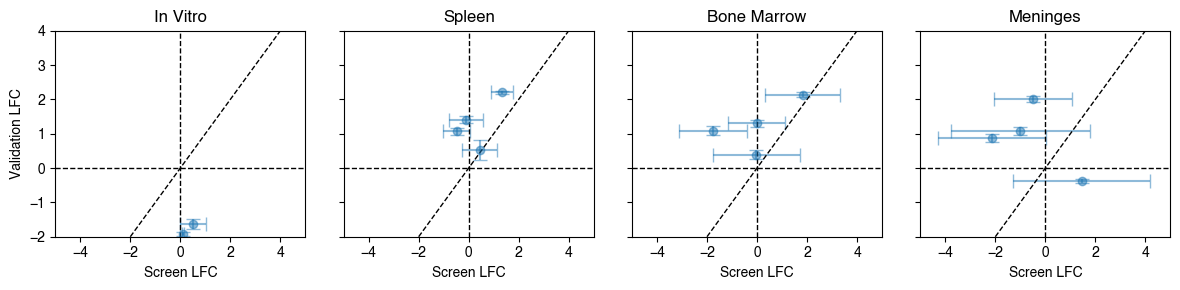

In [469]:
m1 = pd.merge(screen_data_medians, data_val, on='gRNA_id')
m1_ABE = m1[m1['Editor']=='ABE']
m1_CBE = m1[m1['Editor']=='CBE']

fig, ax = plt.subplots(1,4, figsize=(12,3), sharex=True, sharey=True)


#first plot ABE in errorbar format
ax[0].errorbar(m1_ABE['LFC_median_d15'], m1_ABE['median_in-vitro'], xerr=m1_ABE['iv_std'], yerr=m1_ABE['std_in-vitro'], color='tab:purple',fmt='o', capsize=5, alpha=.5)
ax[0].errorbar(m1_CBE['LFC_median_d15'], m1_CBE['median_in-vitro'], xerr=m1_CBE['iv_std'], yerr=m1_CBE['std_in-vitro'], color='tab:blue',fmt='o', capsize=5, alpha=.5)
ax[0].set_title('In Vitro')

ax[1].errorbar(m1_ABE['LFC_median_spleen'], m1_ABE['median_spleen'], xerr=m1_ABE['spleen_std'], yerr=m1_ABE['std_spleen'], color='tab:purple',fmt='o', capsize=5, alpha=.5)
ax[1].errorbar(m1_CBE['LFC_median_spleen'], m1_CBE['median_spleen'], xerr=m1_CBE['spleen_std'], yerr=m1_CBE['std_spleen'], color='tab:blue',fmt='o', capsize=5, alpha=.5)
ax[1].set_title('Spleen')


ax[2].errorbar(m1_ABE['LFC_median_bonemarrow'], m1_ABE['median_bm'], xerr=m1_ABE['bm_std'], yerr=m1_ABE['std_bm'], color='tab:purple',fmt='o', capsize=5, alpha=.5)
ax[2].errorbar(m1_CBE['LFC_median_bonemarrow'], m1_CBE['median_bm'], xerr=m1_CBE['bm_std'], yerr=m1_CBE['std_bm'], color='tab:blue',fmt='o', capsize=5, alpha=.5)
ax[2].set_title('Bone Marrow')


ax[3].errorbar(m1_ABE['LFC_median_meninges'], m1_ABE['median_men'], xerr=m1_ABE['meninges_std'], yerr=m1_ABE['std_men'], color='tab:purple',fmt='o', capsize=5, alpha=.5)
ax[3].errorbar(m1_CBE['LFC_median_meninges'], m1_CBE['median_men'], xerr=m1_CBE['meninges_std'], yerr=m1_CBE['std_men'], color='tab:blue',fmt='o', capsize=5, alpha=.5)
ax[3].set_title('Meninges')

ax[0].set_ylabel('Validation LFC')


for i in range(4):
    ax[i].set_xlabel('Screen LFC')
    ax[i].axvline(0, color='black', linestyle='dashed', linewidth=1)
    ax[i].axhline(0, color='black', linestyle='dashed', linewidth=1)
    ax[i].axline((1, 1), slope=1, color='black',linestyle='dashed', linewidth=1)


ax[0].set_xlim(-5,5)
ax[1].set_ylim(-2,4)
fig.tight_layout()
plt.savefig('figures/5b.pdf')

## 5c

In [410]:
CBE_samp_dict = {'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5','spleen6','spleen7','spleen8','spleen9'],
    'bonemarrow':['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5','bonemarrow6','bonemarrow7','bonemarrow8','bonemarrow9','bonemarrow10'],
    'meninges':['meninges1','meninges2','meninges3','meninges4','meninges5','meninges6','meninges7','meninges8','meninges9','meninges10',],
    'd5':['d5_rep1','d5_rep2','d5_rep3'],
    'd15':['d15_rep1','d15_rep2','d15_rep3'],
    'plasmid_lib':['plasmidlib']}

ABE_samp_dict = {'spleen':['spleen1','spleen2','spleen3','spleen4'],
'bonemarrow':['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
'meninges':['meninges1','meninges2','meninges3','meninges4','meninges5'],
'd5':['d5_rep1','d5_rep2','d5_rep3'],
'd15':['d15_rep1','d15_rep2','d15_rep3'],
'plasmid_lib':['plasmidlib']}

screen_data_ABE = screen_data_OG[screen_data_OG['Editor']=='ABE']
screen_data_CBE = screen_data_OG[screen_data_OG['Editor']=='CBE']

tissue_holder = []
LFC_holder = []
gRNA_holder = []

tissues = ['spleen', 'bonemarrow', 'meninges', 'd15']
tissue_dict = {'spleen':'Spleen', 'bonemarrow': 'Bone Marrow', 'meninges':'Meninges', 'd15':'In Vitro'}
for guide in np.unique(screen_data_ABE['gRNA_id']):
    
    for tissue in tissues:
        a = ABE_samp_dict[tissue]

        for k in a:
            j = screen_data_ABE.loc[screen_data_ABE['gRNA_id']==guide, k].values[0]
            LFC_holder.append(j)
            gRNA_holder.append(guide)
            tissue_holder.append(tissue_dict[tissue])
            
screen_ABE_reformat = pd.DataFrame(dict(zip(['gRNA_id', 'LFC', 'Tissue'], [gRNA_holder, LFC_holder, tissue_holder])))
screen_ABE_reformat['Condition'] = 'Screen'

#----and CBE
tissue_holder = []
LFC_holder = []
gRNA_holder = []

tissues = ['spleen', 'bonemarrow', 'meninges', 'd15']
tissue_dict = {'spleen':'spleen', 'bonemarrow': 'bm', 'meninges':'men', 'd15':'in-vitro'}
for guide in np.unique(screen_data_CBE['gRNA_id']):
    
    for tissue in tissues:
        a = CBE_samp_dict[tissue]

        for k in a:
            j = screen_data_CBE.loc[screen_data_CBE['gRNA_id']==guide, k].values[0]
            LFC_holder.append(j)
            gRNA_holder.append(guide)
            tissue_holder.append(tissue_dict[tissue])
            
screen_CBE_reformat = pd.DataFrame(dict(zip(['gRNA_id', 'LFC', 'Tissue'], [gRNA_holder, LFC_holder, tissue_holder])))
screen_CBE_reformat['Condition'] = 'Screen'


In [411]:
m1_CBE

,gRNA_id,LFC_median_meninges,LFC_median_spleen,LFC_median_bonemarrow,LFC_median_d15,Editor,spleen_std,bm_std,meninges_std,iv_std,median_men,median_spleen,median_in-vitro,median_bm,std_in-vitro,std_spleen,std_bm,std_men
0,gRNA_8498,-0.995149,-0.483570,-1.746966,0.114055,CBE,0.540339,1.354172,2.794162,0.047660,1.069214,1.069214,-1.920830,1.089637,0.072200,0.108507,0.131509,0.117871
1,gRNA_8508,-2.129585,-0.109667,-0.019711,0.295421,CBE,0.681852,1.155409,2.158736,0.198571,0.883149,1.413147,-3.058894,1.307694,0.125865,0.102136,0.104401,0.119120
2,gRNA_8524,-0.502680,1.332405,1.824293,0.503431,CBE,0.424653,1.495711,1.561283,0.523654,2.011054,2.208031,-1.634638,2.133885,0.144130,0.040731,0.068365,0.088277
3,gRNA_8526,1.455434,0.435548,-0.022791,-0.015276,CBE,0.689128,1.737983,2.746504,0.110156,-0.376016,0.527629,-4.473237,0.391425,0.180229,0.301652,0.130724,0.063750


In [412]:
dict_gRNA = dict(zip(Pax5_validation_BE['gRNA_id'], Pax5_validation_BE['Variant']))

In [452]:
# g_order_ABE = list(m1_ABE.sort_values(by='LFC_median_spleen', ascending=False)['gRNA_id'])
# names_ABE = list(m1_ABE.sort_values(by='LFC_median_spleen', ascending=False)['Variant'])
g_order_CBE = list(m1_CBE.sort_values(by='LFC_median_spleen', ascending=False)['gRNA_id'])
names_CBE = [dict_gRNA[x] for x in g_order_CBE]
order_controls = ['KO', 'ST']
names_controls = ['KO', 'ST']
# names_ABE2 = ['Non-targeting\nControl' if x == 'nan nan \nnon_target Non-coding' else x for x in names_ABE]
# names_CBE2 = ['Safe-targeting\nControl' if x == 'nan nan \nsafe_target Non-coding' else x for x in names_CBE]

In [ ]:
Pax5_validation_guides = Pax5_validation_BE_all[Pax5_validation_BE_all['Variant'] != 'ST']
Pax5_validation_KO_controls_all = pd.concat([Pax5_validation_KO, Pax5_validation_ST]).reset_index(drop=True)

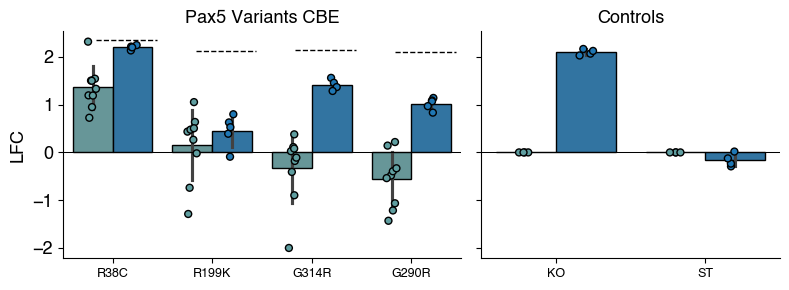

In [464]:
Pax5_validation_BE['Condition'] = 'Validation'
Pax5_validation_BE['Tissue'] = Pax5_validation_BE['Sample']
CBE1 = pd.concat((screen_CBE_reformat, Pax5_validation_BE)).reset_index(drop=True)

Pax5_validation_KO_controls['Condition'] = 'Validation'
Pax5_validation_KO_controls_copy = Pax5_validation_KO_controls.copy()
Pax5_validation_KO_controls_copy['Condition'] = 'Screen'
Pax5_validation_KO_controls_copy['LFC'] = 0
Pax5_validation_KO_controls['Tissue'] = Pax5_validation_KO_controls['Sample']
CONTROLS = pd.concat((Pax5_validation_KO_controls_copy, Pax5_validation_KO_controls)).reset_index(drop=True)

fig, ax = plt.subplots(1,2, figsize=(8,3), width_ratios=[8,6], sharey=True)
tissue = 'spleen'

palette = ['lightgrey','cadetblue','slateblue','lightcoral', '#ED6A50',]
pal_iv = ['lightgrey', 'tab:grey']
pal_spleen = ['cadetblue', 'tab:blue']
pal_bon = ['slateblue', 'indigo']
pal_men = ['lightcoral', 'tab:red']

pal_chosen = pal_spleen
sns.stripplot(data=CBE1[CBE1['Tissue']==tissue], x='gRNA_id', y='LFC', hue='Condition', dodge=True, legend=False, ax=ax[0], palette=pal_chosen, edgecolor='black', linewidth=1, order=g_order_CBE)
sns.barplot(data=CBE1[CBE1['Tissue']==tissue], x='gRNA_id', y='LFC', hue='Condition', errorbar='sd', legend=False,ax=ax[0], edgecolor='black', palette=pal_chosen, linewidth=1, order=g_order_CBE)
sns.stripplot(data=CONTROLS[CONTROLS['Tissue']==tissue], x='Variant', y='LFC', hue='Condition', dodge=True, legend=False, ax=ax[1], edgecolor='black', palette=pal_chosen, linewidth=1, order=order_controls)
sns.barplot(data=CONTROLS[CONTROLS['Tissue']==tissue], x='Variant', y='LFC', hue='Condition', errorbar='sd',legend=False,ax=ax[1], edgecolor='black', palette=pal_chosen, linewidth=1, order=order_controls)

ax[0].axhline(0, color='black',  linewidth=.75)
ax[1].axhline(0, color='black', linewidth=.75)

#plot theoretical maximum LFC for each gRNA given the initial BFP+%
all = pd.concat([Pax5_validation_guides, Pax5_validation_KO_controls_all]).reset_index(drop=True)
initial = all[all['Timepoint']=='D0']
# for i, val in enumerate(g_order_ABE):
#     init = initial.loc[initial['gRNA_id']==val, 'Percent_population'].values[0]
#     ax[0].axhline(np.log2(100/init), xmin=0+i/8+1/16, xmax=i/8 + 1/8-1/90, color='black', linestyle='dashed', linewidth=1)

for i, val in enumerate(g_order_CBE):
    init = initial.loc[initial['gRNA_id']==val, '%BFP+'].values[0]
    ax[0].axhline(np.log2(100/init), xmin=0+i/4+1/12, xmax=i/4 + 1/4-1/70, color='black', linestyle='dashed', linewidth=1)

#ax[1].plot([0,8], [0,0], color='black', linestyle='dashed')
ax[0].spines[['top', 'right']].set_visible(False)
ax[1].spines[['top', 'right']].set_visible(False)

ax[0].tick_params(axis='x', which='major', labelsize=9)
ax[0].tick_params(axis='y', which='major', labelsize=13)

ax[1].tick_params(axis='x', which='major', labelsize=9)

ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[0].set_ylabel('LFC', fontsize=13)

ax[0].set_xticklabels(names_CBE)
ax[1].set_xticklabels(names_controls)
ax[0].set_title('Pax5 Variants CBE', fontsize=13)
ax[1].set_title('Controls', fontsize=13)

plt.savefig('figures/5c.pdf', dpi=300)
fig.tight_layout()

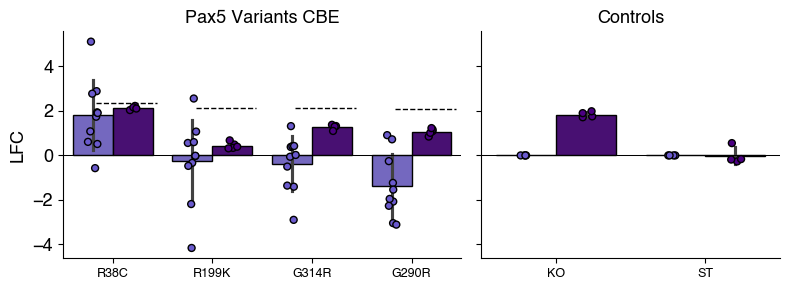

In [465]:
fig, ax = plt.subplots(1,2, figsize=(8,3), width_ratios=[8,6], sharey=True)
tissue = 'bm'

palette = ['lightgrey','cadetblue','slateblue','lightcoral', '#ED6A50',]
pal_iv = ['lightgrey', 'tab:grey']
pal_spleen = ['cadetblue', 'tab:blue']
pal_bon = ['slateblue', 'indigo']
pal_men = ['lightcoral', 'tab:red']

pal_chosen = pal_bon
sns.stripplot(data=CBE1[CBE1['Tissue']==tissue], x='gRNA_id', y='LFC', hue='Condition', dodge=True, legend=False, ax=ax[0], palette=pal_chosen, edgecolor='black', linewidth=1, order=g_order_CBE)
sns.barplot(data=CBE1[CBE1['Tissue']==tissue], x='gRNA_id', y='LFC', hue='Condition', errorbar='sd', legend=False,ax=ax[0], edgecolor='black', palette=pal_chosen, linewidth=1, order=g_order_CBE)
sns.stripplot(data=CONTROLS[CONTROLS['Tissue']==tissue], x='Variant', y='LFC', hue='Condition', dodge=True, legend=False, ax=ax[1], edgecolor='black', palette=pal_chosen, linewidth=1, order=order_controls)
sns.barplot(data=CONTROLS[CONTROLS['Tissue']==tissue], x='Variant', y='LFC', hue='Condition', errorbar='sd',legend=False,ax=ax[1], edgecolor='black', palette=pal_chosen, linewidth=1, order=order_controls)

ax[0].axhline(0, color='black',  linewidth=.75)
ax[1].axhline(0, color='black', linewidth=.75)

#plot theoretical maximum LFC for each gRNA given the initial BFP+%
all = pd.concat([Pax5_validation_guides, Pax5_validation_KO_controls_all]).reset_index(drop=True)
initial = all[all['Timepoint']=='D0']
# for i, val in enumerate(g_order_ABE):
#     init = initial.loc[initial['gRNA_id']==val, 'Percent_population'].values[0]
#     ax[0].axhline(np.log2(100/init), xmin=0+i/8+1/16, xmax=i/8 + 1/8-1/90, color='black', linestyle='dashed', linewidth=1)

for i, val in enumerate(g_order_CBE):
    init = initial.loc[initial['gRNA_id']==val, '%BFP+'].values[0]
    ax[0].axhline(np.log2(100/init), xmin=0+i/4+1/12, xmax=i/4 + 1/4-1/70, color='black', linestyle='dashed', linewidth=1)

#ax[1].plot([0,8], [0,0], color='black', linestyle='dashed')
ax[0].spines[['top', 'right']].set_visible(False)
ax[1].spines[['top', 'right']].set_visible(False)

ax[0].tick_params(axis='x', which='major', labelsize=9)
ax[0].tick_params(axis='y', which='major', labelsize=13)

ax[1].tick_params(axis='x', which='major', labelsize=9)

ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[0].set_ylabel('LFC', fontsize=13)

ax[0].set_xticklabels(names_CBE)
ax[1].set_xticklabels(names_controls)
ax[0].set_title('Pax5 Variants CBE', fontsize=13)
ax[1].set_title('Controls', fontsize=13)


fig.tight_layout()
plt.savefig('figures/5d.pdf', dpi=300)

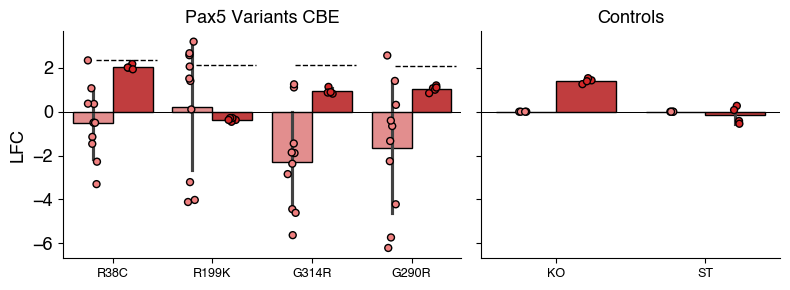

In [467]:
fig, ax = plt.subplots(1,2, figsize=(8,3), width_ratios=[8,6], sharey=True)
tissue = 'men'

palette = ['lightgrey','cadetblue','slateblue','lightcoral', '#ED6A50',]
pal_iv = ['lightgrey', 'tab:grey']
pal_spleen = ['cadetblue', 'tab:blue']
pal_bon = ['slateblue', 'indigo']
pal_men = ['lightcoral', 'tab:red']

pal_chosen = pal_men
sns.stripplot(data=CBE1[CBE1['Tissue']==tissue], x='gRNA_id', y='LFC', hue='Condition', dodge=True, legend=False, ax=ax[0], palette=pal_chosen, edgecolor='black', linewidth=1, order=g_order_CBE)
sns.barplot(data=CBE1[CBE1['Tissue']==tissue], x='gRNA_id', y='LFC', hue='Condition', errorbar='sd', legend=False,ax=ax[0], edgecolor='black', palette=pal_chosen, linewidth=1, order=g_order_CBE)
sns.stripplot(data=CONTROLS[CONTROLS['Tissue']==tissue], x='Variant', y='LFC', hue='Condition', dodge=True, legend=False, ax=ax[1], edgecolor='black', palette=pal_chosen, linewidth=1, order=order_controls)
sns.barplot(data=CONTROLS[CONTROLS['Tissue']==tissue], x='Variant', y='LFC', hue='Condition', errorbar='sd',legend=False,ax=ax[1], edgecolor='black', palette=pal_chosen, linewidth=1, order=order_controls)

ax[0].axhline(0, color='black',  linewidth=.75)
ax[1].axhline(0, color='black', linewidth=.75)

#plot theoretical maximum LFC for each gRNA given the initial BFP+%
all = pd.concat([Pax5_validation_guides, Pax5_validation_KO_controls_all]).reset_index(drop=True)
initial = all[all['Timepoint']=='D0']
# for i, val in enumerate(g_order_ABE):
#     init = initial.loc[initial['gRNA_id']==val, 'Percent_population'].values[0]
#     ax[0].axhline(np.log2(100/init), xmin=0+i/8+1/16, xmax=i/8 + 1/8-1/90, color='black', linestyle='dashed', linewidth=1)

for i, val in enumerate(g_order_CBE):
    init = initial.loc[initial['gRNA_id']==val, '%BFP+'].values[0]
    ax[0].axhline(np.log2(100/init), xmin=0+i/4+1/12, xmax=i/4 + 1/4-1/70, color='black', linestyle='dashed', linewidth=1)

#ax[1].plot([0,8], [0,0], color='black', linestyle='dashed')
ax[0].spines[['top', 'right']].set_visible(False)
ax[1].spines[['top', 'right']].set_visible(False)

ax[0].tick_params(axis='x', which='major', labelsize=9)
ax[0].tick_params(axis='y', which='major', labelsize=13)

ax[1].tick_params(axis='x', which='major', labelsize=9)

ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[0].set_ylabel('LFC', fontsize=13)

ax[0].set_xticklabels(names_CBE)
ax[1].set_xticklabels(names_controls)
ax[0].set_title('Pax5 Variants CBE', fontsize=13)
ax[1].set_title('Controls', fontsize=13)


fig.tight_layout()
plt.savefig('figures/5e.pdf', dpi=300)

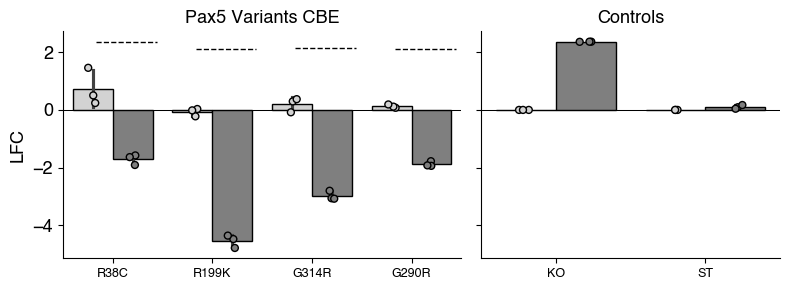

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(8,3), width_ratios=[8,6], sharey=True)
tissue = 'in-vitro'

palette = ['lightgrey','cadetblue','slateblue','lightcoral', '#ED6A50',]
pal_iv = ['lightgrey', 'tab:grey']
pal_spleen = ['cadetblue', 'tab:blue']
pal_bon = ['slateblue', 'indigo']
pal_men = ['lightcoral', 'tab:red']

pal_chosen = pal_iv
sns.stripplot(data=CBE1[CBE1['Tissue']==tissue], x='gRNA_id', y='LFC', hue='Condition', dodge=True, legend=False, ax=ax[0], palette=pal_chosen, edgecolor='black', linewidth=1, order=g_order_CBE)
sns.barplot(data=CBE1[CBE1['Tissue']==tissue], x='gRNA_id', y='LFC', hue='Condition', errorbar='sd', legend=False,ax=ax[0], edgecolor='black', palette=pal_chosen, linewidth=1, order=g_order_CBE)
sns.stripplot(data=CONTROLS[CONTROLS['Tissue']==tissue], x='Variant', y='LFC', hue='Condition', dodge=True, legend=False, ax=ax[1], edgecolor='black', palette=pal_chosen, linewidth=1, order=order_controls)
sns.barplot(data=CONTROLS[CONTROLS['Tissue']==tissue], x='Variant', y='LFC', hue='Condition', errorbar='sd',legend=False,ax=ax[1], edgecolor='black', palette=pal_chosen, linewidth=1, order=order_controls)

ax[0].axhline(0, color='black',  linewidth=.75)
ax[1].axhline(0, color='black', linewidth=.75)

#plot theoretical maximum LFC for each gRNA given the initial BFP+%
all = pd.concat([Pax5_validation_guides, Pax5_validation_KO_controls_all]).reset_index(drop=True)
initial = all[all['Timepoint']=='D0']
# for i, val in enumerate(g_order_ABE):
#     init = initial.loc[initial['gRNA_id']==val, 'Percent_population'].values[0]
#     ax[0].axhline(np.log2(100/init), xmin=0+i/8+1/16, xmax=i/8 + 1/8-1/90, color='black', linestyle='dashed', linewidth=1)

for i, val in enumerate(g_order_CBE):
    init = initial.loc[initial['gRNA_id']==val, '%BFP+'].values[0]
    ax[0].axhline(np.log2(100/init), xmin=0+i/4+1/12, xmax=i/4 + 1/4-1/70, color='black', linestyle='dashed', linewidth=1)

#ax[1].plot([0,8], [0,0], color='black', linestyle='dashed')
ax[0].spines[['top', 'right']].set_visible(False)
ax[1].spines[['top', 'right']].set_visible(False)

ax[0].tick_params(axis='x', which='major', labelsize=9)
ax[0].tick_params(axis='y', which='major', labelsize=13)

ax[1].tick_params(axis='x', which='major', labelsize=9)

ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[0].set_ylabel('LFC', fontsize=13)

ax[0].set_xticklabels(names_CBE)
ax[1].set_xticklabels(names_controls)
ax[0].set_title('Pax5 Variants CBE', fontsize=13)
ax[1].set_title('Controls', fontsize=13)

fig.tight_layout()
plt.savefig('figures/5f.pdf')

In [414]:
val_CBE = Pax5_validation_BE[['gRNA_id', 'LFC', 'Sample']]
val_CBE.columns = ['gRNA_id', 'LFC', 'Tissue']
val_CBE['Condition'] = 'Validation'

In [425]:
val_CBE_2 = Pax5_validation_KO_controls[['gRNA_id', 'LFC', 'Sample']]
val_CBE_2.columns = ['gRNA_id', 'LFC', 'Tissue']
val_CBE_2['Condition'] = 'Validation'

In [422]:
dict_gRNA

{'gRNA_8498': 'G290R',
 'gRNA_8526': 'R199K',
 'gRNA_8508': 'G314R',
 'gRNA_8524': 'R38C'}